# Naive Bayes

Naive Bayes is a supervised machine learning algorithm mainly used for
classification problems.

It is based on **Bayes' Theorem** and makes a simple assumption that the
features are conditionally independent given the class.

Naive Bayes is commonly used for:

- Spam detection
- Text classification
- Sentiment analysis
- Document classification
- Medical diagnosis
- News classification

In this notebook, we will understand Naive Bayes from the mathematical
foundation to a practical implementation using Scikit-Learn.

## Learning Objectives

By the end of this notebook, we will understand:

1. Bayes' Theorem
2. Prior, likelihood, evidence and posterior
3. Naive Bayes classification
4. Conditional independence assumption
5. Mathematical formulation of Naive Bayes
6. Laplace smoothing
7. Types of Naive Bayes
8. Gaussian Naive Bayes
9. Naive Bayes implementation from scratch
10. GaussianNB using Scikit-Learn
11. Model evaluation
12. Prediction probabilities
13. Advantages and limitations

# 2. Bayes' Theorem

Naive Bayes is based on **Bayes' Theorem**.

Bayes' Theorem describes how we can update the probability of an event
when new evidence is available.

The formula is:

P(A | B) = [P(B | A) × P(A)] / P(B)

Where:

- P(A | B) = Posterior probability
- P(B | A) = Likelihood
- P(A) = Prior probability
- P(B) = Evidence

In simple terms:

Posterior = (Likelihood × Prior) / Evidence

In [1]:
# Simple Bayes' Theorem example

P_A = 0.4
P_B_given_A = 0.7
P_B = 0.5

P_A_given_B = (P_B_given_A * P_A) / P_B

print("P(A | B) =", P_A_given_B)

P(A | B) = 0.5599999999999999


### Interpretation

The result represents the probability of event A occurring given that
event B has already occurred.

Bayes' Theorem is the mathematical foundation of the Naive Bayes
classification algorithm.

## 3. Components of Bayes' Theorem

### 1. Prior Probability

The probability of a class before observing the features.

P(Class)

---

### 2. Likelihood

The probability of observing the features given a particular class.

P(Features | Class)

---

### 3. Evidence

The overall probability of observing the features.

P(Features)

---

### 4. Posterior Probability

The probability of a class after observing the features.

P(Class | Features)

Therefore:

Posterior ∝ Likelihood × Prior

# 4. Numerical Example

Suppose we want to classify an email as:

- Spam
- Not Spam

Assume:

P(Spam) = 0.4

P(Free | Spam) = 0.8

P(Free | Not Spam) = 0.1

P(Not Spam) = 0.6

We want to calculate:

P(Spam | Free)

Using Bayes' Theorem:
```text
P(Spam | Free)
=
P(Free | Spam) × P(Spam)
--------------------------------
P(Free)

In [2]:
P_spam = 0.4
P_not_spam = 0.6

P_free_given_spam = 0.8
P_free_given_not_spam = 0.1

# Calculate P(Free)
P_free = (
    P_free_given_spam * P_spam
    + P_free_given_not_spam * P_not_spam
)

# Calculate P(Spam | Free)
P_spam_given_free = (
    P_free_given_spam * P_spam
    / P_free
)

# Calculate P(Not Spam | Free)
P_not_spam_given_free = (
    P_free_given_not_spam * P_not_spam
    / P_free
)

print("P(Free) =", P_free)
print("P(Spam | Free) =", P_spam_given_free)
print("P(Not Spam | Free) =", P_not_spam_given_free)

P(Free) = 0.38000000000000006
P(Spam | Free) = 0.8421052631578948
P(Not Spam | Free) = 0.15789473684210523


### Result

The probability of Spam given the word "Free" is higher than the
probability of Not Spam.

Therefore, the Naive Bayes classifier would predict:

**Spam**

# 5. Naive Bayes Classifier

```text
For a classification problem, suppose we have:

- Classes: C
- Features: X₁, X₂, ..., Xₙ

We want to calculate:

P(C | X₁, X₂, ..., Xₙ)

Using Bayes' Theorem:

P(C | X₁, ..., Xₙ)
=
P(X₁, ..., Xₙ | C) × P(C)
----------------------------------
P(X₁, ..., Xₙ)

The denominator is the same for every class.

Therefore, for classification we can compare:

P(C | X)
∝
P(X | C) × P(C)

## 6. The "Naive" Assumption

```text
The word "Naive" comes from a strong assumption about the features.

Naive Bayes assumes that the features are **conditionally independent**
given the class.

Therefore:

P(X₁, X₂, ..., Xₙ | C)

=

P(X₁ | C) × P(X₂ | C) × ... × P(Xₙ | C)

So the Naive Bayes formula becomes:

P(C | X₁, ..., Xₙ)
∝
P(C) × ∏ P(Xᵢ | C)

The predicted class is the class with the highest probability.

# 7. Simple Classification Example

Suppose an email contains two words:

- "Free"
- "Offer"

We want to classify the email as:

- Spam
- Not Spam

Naive Bayes calculates:

P(Spam) × P(Free | Spam) × P(Offer | Spam)

and

P(Not Spam) × P(Free | Not Spam) × P(Offer | Not Spam)

The class with the larger score is selected.

In [3]:
# Prior probabilities
P_spam = 0.4
P_not_spam = 0.6

# Likelihoods
P_free_given_spam = 0.8
P_offer_given_spam = 0.7

P_free_given_not_spam = 0.1
P_offer_given_not_spam = 0.2

# Naive Bayes scores
spam_score = (
    P_spam
    * P_free_given_spam
    * P_offer_given_spam
)

not_spam_score = (
    P_not_spam
    * P_free_given_not_spam
    * P_offer_given_not_spam
)

print("Spam score:", spam_score)
print("Not Spam score:", not_spam_score)

if spam_score > not_spam_score:
    print("Prediction: Spam")
else:
    print("Prediction: Not Spam")

Spam score: 0.22400000000000003
Not Spam score: 0.012
Prediction: Spam


## 8. Normalizing the Scores

The scores can be converted into actual probabilities.

For Spam:

P(Spam | X) = Spam Score / (Spam Score + Not Spam Score)

For Not Spam:

P(Not Spam | X) = Not Spam Score /
                  (Spam Score + Not Spam Score)

In [4]:
total_score = spam_score + not_spam_score

spam_probability = spam_score / total_score
not_spam_probability = not_spam_score / total_score

print("P(Spam | X) =", spam_probability)
print("P(Not Spam | X) =", not_spam_probability)

P(Spam | X) = 0.9491525423728813
P(Not Spam | X) = 0.050847457627118633


# 9. Laplace Smoothing

```text
A major problem can occur when a likelihood is zero.

For example:

P(Word | Spam) = 0

Since Naive Bayes multiplies probabilities:

P(Spam) × P(Word₁ | Spam) × P(Word₂ | Spam) × ...

a single zero probability makes the complete score zero.

To solve this problem, Naive Bayes can use **Laplace smoothing**.

Formula:

P(X | C) = (Count(X, C) + α)
           --------------------
           Count(C) + αK

Where:

- α = smoothing parameter
- K = number of possible feature values

Usually:

α = 1

This is called **Add-One Smoothing**.

# 10. Types of Naive Bayes

There are several commonly used versions of Naive Bayes.

### 1. Gaussian Naive Bayes

Used mainly for continuous numerical features.

Examples:

- Age
- Height
- Weight
- Temperature
- Salary

---

### 2. Multinomial Naive Bayes

Commonly used for text classification.

Examples:

- Spam detection
- Document classification
- News classification

---

### 3. Bernoulli Naive Bayes

Used when features are binary.

Examples:

- Word present / absent
- Yes / No
- 0 / 1

---

In this notebook, we will first focus on **Gaussian Naive Bayes**.

# 11. Gaussian Naive Bayes

```text
Gaussian Naive Bayes is used when the features are continuous numerical
values.

It assumes that the feature values follow a Gaussian (normal)
distribution within each class.

The Gaussian probability density function is:

P(x | C)
=
1 / √(2πσ²)
×
e^[-(x - μ)² / (2σ²)]

Where:

- x = observed feature value
- μ = mean of the feature for the class
- σ² = variance of the feature for the class
- π = mathematical constant
- e = Euler's number

## Gaussian Distribution

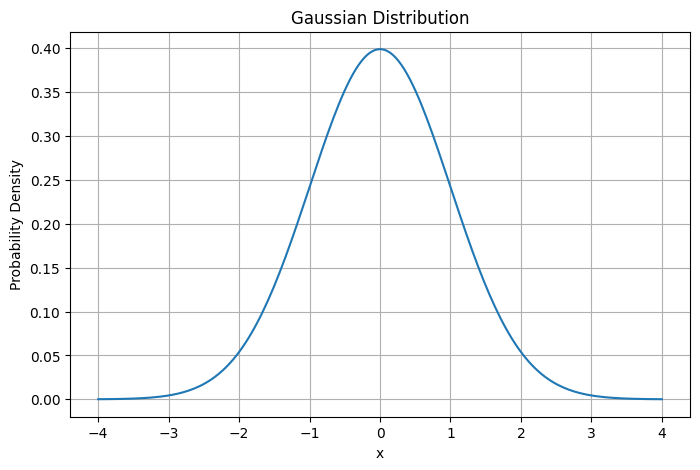

In [5]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-4, 4, 200)

mean = 0
variance = 1
std = np.sqrt(variance)

pdf = (
    1 / (std * np.sqrt(2 * np.pi))
    * np.exp(
        -((x - mean) ** 2) / (2 * variance)
    )
)

plt.figure(figsize=(8, 5))

plt.plot(x, pdf)

plt.title("Gaussian Distribution")
plt.xlabel("x")
plt.ylabel("Probability Density")

plt.grid(True)
plt.show()

# 13. Gaussian Naive Bayes From Scratch

Before using Scikit-Learn, let's understand the basic idea by
implementing Gaussian Naive Bayes ourselves.

We will create a small dataset with two numerical features.

Features:

- Height
- Weight

Target:

- Class 0
- Class 1

In [6]:
import numpy as np

X = np.array([
    [150, 50],
    [155, 52],
    [160, 55],
    [165, 60],
    [170, 65],
    [175, 70],
    [180, 75],
    [185, 80]
])

y = np.array([
    0, 0, 0, 0,
    1, 1, 1, 1
])

print("Features:")
print(X)

print("\nTarget:")
print(y)

Features:
[[150  50]
 [155  52]
 [160  55]
 [165  60]
 [170  65]
 [175  70]
 [180  75]
 [185  80]]

Target:
[0 0 0 0 1 1 1 1]


## 14. Calculate Class Statistics

Gaussian Naive Bayes needs:

- Mean of every feature for each class
- Variance of every feature for each class
- Prior probability of each class

In [7]:
classes = np.unique(y)

means = {}
variances = {}
priors = {}

for c in classes:
    X_c = X[y == c]

    means[c] = np.mean(X_c, axis=0)
    variances[c] = np.var(X_c, axis=0)
    priors[c] = len(X_c) / len(X)

    print(f"Class {c}")
    print("Mean:", means[c])
    print("Variance:", variances[c])
    print("Prior:", priors[c])
    print()

Class 0
Mean: [157.5   54.25]
Variance: [31.25   14.1875]
Prior: 0.5

Class 1
Mean: [177.5  72.5]
Variance: [31.25 31.25]
Prior: 0.5



## Gaussian Probability Density Function

We now create a function to calculate:

P(x | C)

using the Gaussian probability density formula.

In [8]:
def gaussian_probability(x, mean, variance):
    exponent = np.exp(
        -((x - mean) ** 2) / (2 * variance)
    )

    return (
        1 / np.sqrt(2 * np.pi * variance)
    ) * exponent

## Make a Prediction

In [9]:
def predict(X_sample):
    class_scores = {}

    for c in classes:
        probabilities = gaussian_probability(
            X_sample,
            means[c],
            variances[c]
        )

        score = priors[c] * np.prod(probabilities)

        class_scores[c] = score

    prediction = max(
        class_scores,
        key=class_scores.get
    )

    return prediction, class_scores

In [10]:
sample = np.array([172, 68])

prediction, scores = predict(sample)

print("Sample:", sample)
print("Class scores:", scores)
print("Prediction:", prediction)

Sample: [172  68]
Class scores: {np.int64(0): np.float64(1.670103287908935e-07), np.int64(1): np.float64(0.001135089674100474)}
Prediction: 1


# 17. Gaussian Naive Bayes with Scikit-Learn

Now that we understand the mathematical foundation, we can use
Scikit-Learn's implementation.

We will use the Iris dataset.

Workflow:

1. Load dataset
2. Separate features and target
3. Split into training and testing data
4. Train Gaussian Naive Bayes
5. Make predictions
6. Evaluate the model
7. Visualize the confusion matrix
8. Examine prediction probabilities

## Import Libraries

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

## Load Dataset

In [12]:
iris = load_iris()

X = iris.data
y = iris.target

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Classes:", iris.target_names)

Feature shape: (150, 4)
Target shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']


## Create DataFrame

In [13]:
iris_df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

iris_df["target"] = y

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Inspect Dataset

In [14]:
print("Dataset shape:", iris_df.shape)

print("\nClass distribution:")
print(iris_df["target"].value_counts())

print("\nMissing values:")
print(iris_df.isnull().sum())

Dataset shape: (150, 5)

Class distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


## Train-Test Split

We divide the dataset into:

- Training data → used to train the model
- Testing data → used to evaluate the model

We use 80% for training and 20% for testing.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


## Create Model

In [16]:
model = GaussianNB()

print(model)

GaussianNB()


## Train Model

In [17]:
model.fit(
    X_train,
    y_train
)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


## Make Predictions

In [18]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


## Compare Actual vs Predicted

In [19]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,0,0
1,2,2
2,1,1
3,1,1
4,0,0
5,1,1
6,0,0
7,0,0
8,2,2
9,1,1


# 27. Model Accuracy

Accuracy measures the proportion of correctly classified observations.
```
Formula:

Accuracy =
Correct Predictions
-------------------
Total Predictions

In [20]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


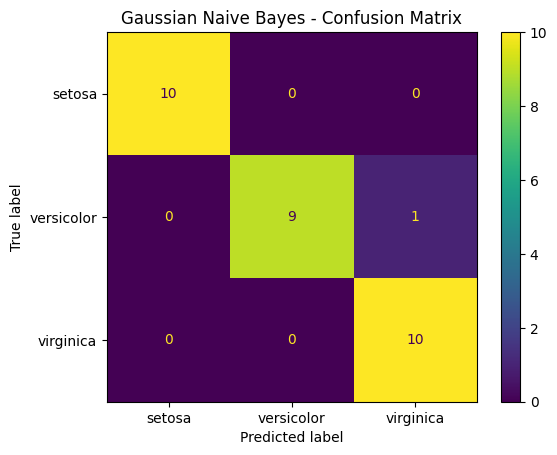

In [21]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()

plt.title("Gaussian Naive Bayes - Confusion Matrix")
plt.show()

## Classification Report

In [22]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



# Prediction Probabilities

Naive Bayes can provide the probability of each class.

We can use:

model.predict_proba()

This is useful when we want to know not only the predicted class but
also how strongly the model supports that prediction.

In [24]:
probabilities = model.predict_proba(X_test)

print(probabilities[:5])

[[1.00000000e+000 2.10423610e-020 1.24046690e-025]
 [8.47878473e-143 8.77457913e-002 9.12254209e-001]
 [2.60594992e-036 9.99999490e-001 5.10180517e-007]
 [1.34650506e-036 9.99999567e-001 4.32500853e-007]
 [1.00000000e+000 6.60692071e-021 6.79224134e-026]]


## Understand One Prediction

In [25]:
sample = X_test[0].reshape(1, -1)

prediction = model.predict(sample)
probability = model.predict_proba(sample)

print("Sample:", sample)
print("Predicted class:", iris.target_names[prediction[0]])

print("\nClass probabilities:")

for class_name, prob in zip(
    iris.target_names,
    probability[0]
):
    print(f"{class_name}: {prob:.4f}")

Sample: [[4.4 3.  1.3 0.2]]
Predicted class: setosa

Class probabilities:
setosa: 1.0000
versicolor: 0.0000
virginica: 0.0000


#  Visualizing the Predictions

For visualization, we will use two features:

- Sepal Length
- Sepal Width

This allows us to visualize how the classes are distributed.

Note that the model itself was trained using all four features.

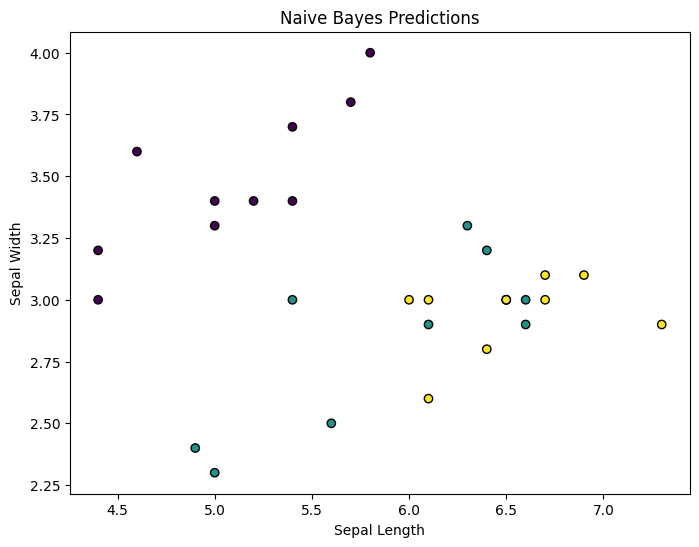

In [26]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_pred,
    edgecolor="black"
)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Naive Bayes Predictions")

plt.show()

#  Advantages of Naive Bayes

### Advantages

- Simple and easy to understand
- Fast to train
- Fast prediction
- Works well with high-dimensional data
- Requires relatively little training data
- Very effective for many text classification problems
- Can provide class probabilities

#  Limitations of Naive Bayes

### Limitations

- The conditional independence assumption may not be true.
- Correlated features can reduce performance.
- Zero-frequency problems can occur without smoothing.
- Gaussian Naive Bayes assumes a Gaussian distribution for numerical
  features.
- It may not capture complex relationships between features.

#  When Should We Use Naive Bayes?

Naive Bayes is a good choice when:

- The problem is classification.
- A fast model is required.
- The dataset has many features.
- The features are relatively independent.
- We are working with text data.
- We need probability estimates.

Typical applications:

- Spam detection
- Sentiment analysis
- News classification
- Document classification
- Medical classification

#  Summary

```text
Naive Bayes is a probabilistic classification algorithm based on
Bayes' Theorem.

The fundamental equation is:

P(C | X) ∝ P(X | C) × P(C)

With the Naive assumption:

P(X | C)
=
P(X₁ | C) × P(X₂ | C) × ... × P(Xₙ | C)

Therefore:

P(C | X)
∝
P(C) × ∏ P(Xᵢ | C)

Important concepts:

- Bayes' Theorem
- Prior probability
- Likelihood
- Evidence
- Posterior probability
- Conditional independence
- Laplace smoothing
- Gaussian Naive Bayes
- Multinomial Naive Bayes
- Bernoulli Naive Bayes

Naive Bayes is especially useful for fast and effective classification,
particularly for text-related problems.